In [1]:
import os
import re
import numpy as np
import tifffile
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
from natsort import natsorted
import pandas as pd
import glob

import matplotlib.patches as mpatches
import matplotlib.path as mpath 
from matplotlib.collections import PathCollection

In [69]:
# Function to sort files naturally
def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

# # Function to calculate SSIM
# def calculate_ssim(original_file, compressed_file):
#     ssim_scores = []
#     with tifffile.TiffFile(original_file) as tif_original:
#         with tifffile.TiffFile(compressed_file) as tif_compressed:
#             for original_frame, compressed_frame in zip(tif_original.series[0].pages, tif_compressed.series[0].pages):
#                 original_image = original_frame.asarray()
#                 compressed_image = compressed_frame.asarray()
#                 score = ssim(original_image, compressed_image, data_range=compressed_image.max() - compressed_image.min())
#                 ssim_scores.append(score)
#     return np.median(ssim_scores) 

# New function to calculate SSIM
def calculate_ssim(original_folder, compressed_folder):
    ssim_results = []
    original_files = natsorted([f for f in os.listdir(original_folder) if f.endswith('.tiff') and not f.startswith('.')])
    compressed_files = natsorted([f for f in os.listdir(compressed_folder) if f.endswith('.tiff') and not f.startswith('.')])
    
    for original_file, compressed_file in zip(original_files, compressed_files):
        ssim_scores = []
        try:
            with tifffile.TiffFile(os.path.join(original_folder, original_file)) as tif_original:
                with tifffile.TiffFile(os.path.join(compressed_folder, compressed_file)) as tif_compressed:
                    for original_frame, compressed_frame in zip(tif_original.series[0].pages, tif_compressed.series[0].pages):
                        original_image = original_frame.asarray()
                        compressed_image = compressed_frame.asarray()
                        score = ssim(original_image, compressed_image, data_range=compressed_image.max() - compressed_image.min())
                        ssim_scores.append(score)
            if ssim_scores:
                median_ssim = np.median(ssim_scores)
                ssim_results.append({'original_file': original_file, 'compressed_file': compressed_file, 'ssim': median_ssim})
        except Exception as e:
            print(f"Error processing files {original_file} and {compressed_file}: {e}")
    return ssim_results


# Function to get the total size of files in a folder
def get_total_size_of_files(folder_path, file_extensions):
    total_size = 0
    for file in os.listdir(folder_path):
        if any(file.endswith(ext) for ext in file_extensions):
            total_size += os.path.getsize(os.path.join(folder_path, file))
    return total_size

# Function to extract the k and lev values from the label
def extract_k_lev(label):
    """
    Extracts the k and lev values from the label.
    Assumes the label format is like 'sparz_k5_rt35_lev0'.
    """
    k_match = re.search(r'_k(\d+)_', label)
    lev_match = re.search(r'_lev(\d+)', label)
    k_value = int(k_match.group(1)) if k_match else None
    lev_value = int(lev_match.group(1)) if lev_match else None
    return k_value, lev_value

# Genomic data

In [64]:
# Nir et al data
main_folder = '/Volumes/T7/compression/Nir_et_al_grid-search'
original_files = '/Users/laurabreimann/Desktop/nir_raw/raw_16bit'


In [65]:
# Get orginal file size from all tiff files
original_file_size = get_total_size_of_files(original_files, ['.tiff'])
print(f'Original file size: {original_file_size / 1e6:.2f} MB')

Original file size: 15892.81 MB


In [66]:
# Create CSV file of SSIM and file size
ssim_df_list = []
for folder in natsorted(os.listdir(main_folder)):
    if folder.startswith('.'):
        continue
    print(folder)
    uncompressed_folder = os.path.join(main_folder, folder, 'uncompressed')
    
    ssim_results = calculate_ssim(original_files, uncompressed_folder)
    total_file_size = get_total_size_of_files(os.path.join(main_folder, folder), ['.mp4', '.npz'])
    print(f'Total file size: {total_file_size / 1e6:.2f} MB')
    file_size_percentage = (total_file_size / original_file_size) * 100
    print(f'File size percentage: {file_size_percentage:.2f}%')
    k, lev = extract_k_lev(folder)
    threshold = int(re.search(r'rt(\d+)', folder).group(1)) 
    
    for result in ssim_results:
        ssim_df_list.append({'Folder': folder, 'original_file': result['original_file'], 'compressed_file': result['compressed_file'], 'SSIM': result['ssim'], 'Size': total_file_size, 'percentage_size': file_size_percentage, 'k': k, 'lev': lev, 'threshold': threshold})

ssim_df = pd.DataFrame(ssim_df_list)
ssim_df.to_csv('/Users/laurabreimann/Desktop/nir_ssim.csv', index=False)

sparz_k7_rt15_lev0
Total file size: 25823.76 MB
File size percentage: 162.49%
sparz_k7_rt15_lev1
Total file size: 18970.68 MB
File size percentage: 119.37%
sparz_k7_rt15_lev2
Total file size: 18046.99 MB
File size percentage: 113.55%
sparz_k7_rt15_lev3
Total file size: 16149.45 MB
File size percentage: 101.61%
sparz_k7_rt25_lev0
Total file size: 23938.68 MB
File size percentage: 150.63%
sparz_k7_rt25_lev1
Total file size: 17085.60 MB
File size percentage: 107.51%
sparz_k7_rt25_lev2
Total file size: 16161.92 MB
File size percentage: 101.69%
sparz_k7_rt25_lev3
Total file size: 14264.38 MB
File size percentage: 89.75%
sparz_k7_rt35_lev0
Total file size: 18662.07 MB
File size percentage: 117.42%
sparz_k7_rt35_lev1
Total file size: 11808.99 MB
File size percentage: 74.30%
sparz_k7_rt35_lev2
Total file size: 10885.30 MB
File size percentage: 68.49%
sparz_k7_rt35_lev3
Total file size: 8987.77 MB
File size percentage: 56.55%
sparz_k7_rt45_lev0
Total file size: 14198.58 MB
File size percentage:

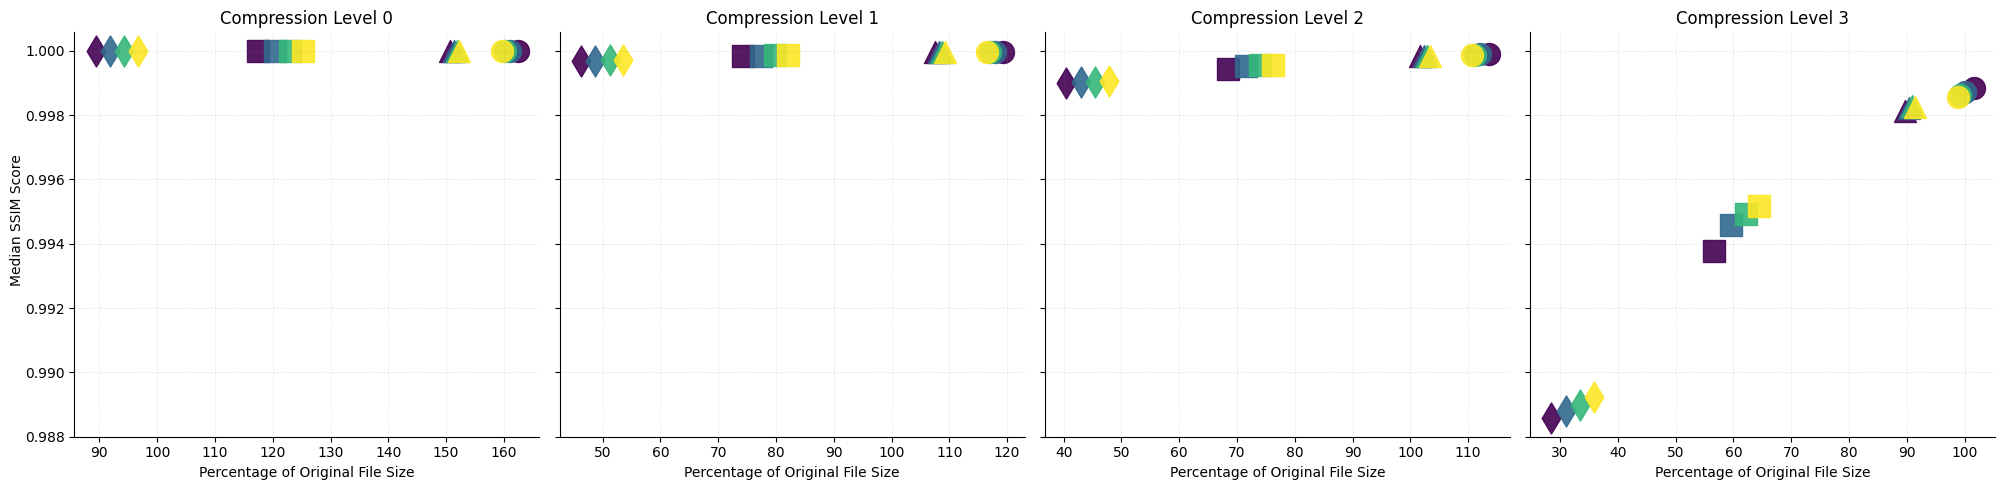

In [68]:
# Read the CSV file
csv_file = '/Users/laurabreimann/Desktop/nir_ssim.csv'
ssim_df = pd.read_csv(csv_file)

# Define colors and markers based on provided specifications
k_values = [7, 9, 11, 13]
k_colors = plt.cm.viridis(np.linspace(0, 1, len(k_values)))
threshold_markers = {15: 'o', 25: '^', 35: 's', 45: 'd'}

# Create a color map for 'k' values
color_map = {k: color for k, color in zip(k_values, k_colors)}

# Calculate the median of medians for SSIM for each folder
folder_stats = ssim_df.groupby('Folder').agg({
    'SSIM': 'median',  # Median of medians for SSIM
    'percentage_size': 'first',  # File size percentage (same for all files in the folder)
    'k': 'first',
    'lev': 'first',
    'threshold': 'first'
}).reset_index()

# Create facet plot
fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for i, (level, group) in enumerate(folder_stats.groupby('lev')):
    ax = axs[i]
    ax.set_xlabel('Percentage of Original File Size')
    ax.set_title(f'Compression Level {level}')
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.2, zorder=0)
    for k, data in group.groupby('k'):
        for rt, rt_data in data.groupby('threshold'):
            if rt in threshold_markers:
                ax.scatter(rt_data['percentage_size'], rt_data['SSIM'], 
                           color=color_map[k], 
                           s=250, 
                           marker=threshold_markers[rt], 
                           alpha=0.9, 
                           label=f'k={k}, rt={rt}')
    #ax.set_xlim(0, 50)

# Remove lines on top and right
for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Set common Y axis label
fig.text(0, 0.55, 'Median SSIM Score', va='center', rotation='vertical')

# Add a legend
handles, labels = ax.get_legend_handles_labels()
#fig.legend(handles, labels, loc='upper right')

plt.tight_layout()

# Save the plot as a PDF
output_file = '/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/Figure_3a_SSIM_filesize_240528.pdf'
plt.savefig(output_file, format='pdf')
#plt.close()

# Astigmatism data

In [9]:

# Change these paths according to your directory structure
main_folder = '/Users/laurabreimann/Desktop/astigmatism'
original_file = '/Users/laurabreimann/Desktop/astigmatism_raw/sequence-as-stack-MT0.N1.HD-AS-Exp.tif'

In [10]:

# Original file size
original_file_size = 20822904   # in bytes


# Color map for kernel sizes
k_colors = plt.cm.viridis(np.linspace(0, 1, 4))
lev_shades = np.linspace(0.5, 1, 4)
k_values = [5,7,9,11]

# Marker map for threshold values
threshold_markers = {35: 'o', 45: '^', 55: 's', 65: 'd'}

# Iterate through each subfolder and calculate median SSIM score and file size
results = {}
for folder in sorted(os.listdir(main_folder), key=natural_sort_key):
    if os.path.isdir(os.path.join(main_folder, folder)):
        uncompressed_folder = os.path.join(main_folder, folder, 'uncompressed')
        # Handling different file endings by searching for the common beginning
        for file_name in os.listdir(uncompressed_folder):
            if file_name.startswith('MT0_sequence-as-stack-MT0.N1'):
                compressed_file = os.path.join(uncompressed_folder, file_name)
                break
        median_ssim = calculate_ssim(original_file, compressed_file)
        total_file_size = get_total_size_of_files(os.path.join(main_folder, folder), ['.mp4', '.npz'])  
        file_size_percentage = (total_file_size / original_file_size) * 100
        k_value, lev_value = extract_k_lev(folder)
        threshold = int(re.search(r'rt(\d+)', folder).group(1))  # Extract threshold value

        # Choose marker based on threshold value
        marker = threshold_markers[threshold]

        color = k_colors[k_values.index(k_value)]

        # Choose shade based on lev value
        shade = lev_shades[lev_value] if lev_value is not None else 0.5

        if lev_value not in results:
            results[lev_value] = []
        results[lev_value].append({'median_ssim': median_ssim, 'file_size_percentage': file_size_percentage, 'color': color, 'shade': shade, 'marker': marker })



In [15]:
# Create facet plot
fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for i, (level, data_list) in enumerate(sorted(results.items())):
    ax = axs[i]
    ax.set_xlabel('Percentage of Original File Size')
    ax.set_title(f'Compression Level {level}')
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.2, zorder=0)
    for data in data_list:
        ax.scatter(data['file_size_percentage'], data['median_ssim'], color=data['color'],s=250, marker=data['marker'], alpha=0.9)
    ax.set_xlim(0, 50)

# Remove lines on top and right
for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Set common Y axis label
fig.text(0, 0.55, 'Median SSIM Score', va='center', rotation='vertical')

plt.tight_layout()
#plt.show()

# Save the plot as a PDF
output_file = '/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/Figure_3_SSIM_filesize_240422.pdf'
plt.tight_layout()
plt.savefig(output_file, format='pdf')
plt.close()

# DNA PAINT

In [3]:

main_folder = '/Users/laurabreimann/Desktop/DNA-PAINT_2'
original_file = '/Users/laurabreimann/Desktop/DNA-PAINT_raw/RawFramesforTraining_P5-IS_20pM.tif'


In [4]:
# Original file size
original_file_size = 2644997930    # in bytes


# Color map for kernel sizes
k_colors = plt.cm.viridis(np.linspace(0, 1, 4))
lev_shades = np.linspace(0.5, 1, 4)
k_values = [11,15,19,23]

# Marker map for threshold values
threshold_markers = {5: 'o', 25: '^', 45: 's', 65: 'd'}
#threshold_markers = {5: 'o', 7: 'v', 10: 'p', 12: '*', 15: '^', 16: '1', 17: 'P', 18: 'x', 19: '>',  25: 's', 35: 'd'}

# Iterate through each subfolder and calculate median SSIM score and file size
results = {}
for folder in sorted(os.listdir(main_folder), key=natural_sort_key):
    if os.path.isdir(os.path.join(main_folder, folder)):
        uncompressed_folder = os.path.join(main_folder, folder, 'uncompressed')
        # Handling different file endings by searching for the common beginning
        for file_name in os.listdir(uncompressed_folder):
            if file_name.startswith('PAINT'):
                compressed_file = os.path.join(uncompressed_folder, file_name)
                break
        median_ssim = calculate_ssim(original_file, compressed_file)
        total_file_size = get_total_size_of_files(os.path.join(main_folder, folder), ['.mp4', '.npz'])  
        file_size_percentage = (total_file_size / original_file_size) * 100
        k_value, lev_value = extract_k_lev(folder)
        threshold = int(re.search(r'rt(\d+)', folder).group(1))  # Extract threshold value

        # Choose marker based on threshold value
        marker = threshold_markers[threshold]

        color = k_colors[k_values.index(k_value)]

        # Choose shade based on lev value
        shade = lev_shades[lev_value] if lev_value is not None else 0.5

        if lev_value not in results:
            results[lev_value] = []
        results[lev_value].append({'median_ssim': median_ssim, 'file_size_percentage': file_size_percentage, 'color': color, 'shade': shade, 'marker': marker })

In [7]:
#show results table
df = pd.DataFrame(results)  
save_path = '/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/Results_DNA-PAINT_240422.csv'
df.to_csv(save_path)
print(df)

                                                    0  \
0   {'median_ssim': 0.9978457467863525, 'file_size...   
1   {'median_ssim': 0.9929620081803741, 'file_size...   
2   {'median_ssim': 0.9929156320759293, 'file_size...   
3   {'median_ssim': 0.992895492846385, 'file_size_...   
4   {'median_ssim': 0.9977835604326378, 'file_size...   
5   {'median_ssim': 0.9930673689896411, 'file_size...   
6   {'median_ssim': 0.9929553406521919, 'file_size...   
7   {'median_ssim': 0.9929001635041025, 'file_size...   
8   {'median_ssim': 0.9977720826050469, 'file_size...   
9   {'median_ssim': 0.9932228530274059, 'file_size...   
10  {'median_ssim': 0.9930137451773292, 'file_size...   
11  {'median_ssim': 0.9929077165802644, 'file_size...   
12  {'median_ssim': 0.9977557786008683, 'file_size...   
13  {'median_ssim': 0.993403740186088, 'file_size_...   
14  {'median_ssim': 0.9930800882942815, 'file_size...   
15  {'median_ssim': 0.9929166461610858, 'file_size...   

                              

In [5]:
# Create facet plot
fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for i, (level, data_list) in enumerate(sorted(results.items())):
    ax = axs[i]
    ax.set_xlabel('Percentage of Original File Size')
    ax.set_title(f'Compression Level {level}')
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.2, zorder=0)
    for data in data_list:
        ax.scatter(data['file_size_percentage'], data['median_ssim'], color=data['color'],s=250, marker=data['marker'], alpha=0.9)
    ax.set_xlim(0, 45)

# Remove lines on top and right
for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Set common Y axis label
fig.text(0, 0.55, 'Median SSIM Score', va='center', rotation='vertical')

plt.tight_layout()
#plt.show()

# Save the plot as a PDF
output_file = '/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/Figure_3_SSIM_filesize_DNA-PAINT_240518.pdf'
plt.tight_layout()
plt.savefig(output_file, format='pdf')
plt.close()